# 025 — Training: `unet_residual` and the `combined_loss` alpha sweep

Trains the **residual-head** variant of `unet` (`scripts/unet_residual.py`) and, on
that architecture, sweeps the one weight of the shared `combined_loss`:

    loss = alpha * Charbonnier  +  (1 - alpha) * (1 - MS-SSIM)

Two questions, deliberately kept separate:

1. **Does the residual head help?** `unet_residual` at `alpha = settings.LOSS_ALPHA`
   (0.16) against the existing `unet` checkpoint from `020_training.ipynb`. Same
   backbone, same recipe, same split, same seed — the *only* difference is the output
   head, so the comparison is clean.
2. **Where should the fidelity/structure trade-off sit?** The same architecture at
   `alpha ∈ {0.16, 0.50, 0.84}`: MS-SSIM-heavy, balanced, pixel-heavy.

**What the residual head is.** `unet` predicts IR directly with a sigmoid `1x1` conv.
`unet_residual` predicts a *signed* residual with a `tanh` `1x1` conv, adds it to
`mean(R, G, B)`, and clips back to `[0, 1]`:

    IR_pred = clip(mean(R, G, B) + tanh_residual, 0, 1)

The reference level costs no parameters, so the network only has to learn where IR
*departs* from the visible grey level — standard global residual learning (VDSR, Kim
et al. 2016; DnCNN, Zhang et al. 2017). The clip is a straight-through estimator
(`scripts/residual_head.py`): exact in the forward pass, transparent in the backward
one, so a pixel pushed out of range still receives a gradient instead of dying.

**Why this may not work here, and why it is still worth a run.** `mean(R, G, B)` is a
weak infrared prior — IR reflectance is not visible luminance, and pigments with the
same grey value can be IR-opaque or IR-transparent (a dark blue is typically
transparent). If the required residual turns out large and structured, the "identity
is free" advantage disappears. That is an empirical question about *these* paintings.

**Why alpha matters for this head specifically.** The residual head changes what the
two loss terms act on. Charbonnier now penalises the residual's absolute error, while
MS-SSIM sees the *reconstruction* — which already inherits all of the RGB's
high-frequency structure through the free grey path. The `alpha = 0.16` optimum that
`fixing.md` #9 imported from Zhao et al. (2016) was measured on a direct-prediction
head; there is no reason it transfers unchanged, hence the sweep rather than a single
run.

**What this notebook does not decide.** No detection metric is computed here. Rank
these checkpoints in `033_evaluation_variants.ipynb` (pixel fidelity) and
`040`/`050` (AUROC/coherence) before drawing a conclusion, and read `024`'s §6 caveat
first: across `C0`+`C1`, detection AUROC correlates with *worse* reconstruction
(Spearman `rho = +0.665`, `p = 0.005`), so the two rankings can disagree for reasons
that have nothing to do with the head.


Make the project root importable so `scripts.*` resolves regardless of the notebook's working directory.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports, a fixed global seed, and a GPU sanity check.

In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import (
    build_dataset,
    load_image_pairs,
    mockup_aware_train_val_test_split,
)
from scripts.reproducibility import set_global_seed
from scripts.trainer import get_model
from scripts.visualization import plot_training_curves

set_global_seed()

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")
print(f"TensorFlow version: {tf.__version__}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.16.2


## 1. Dataset — artwork-and-mockups split

Same split as `020`/`021`/`022`/`023`/`024` §1 — required so these checkpoints are
trained and evaluated under the same conditions as the `unet` baseline they are
compared against.

In [3]:
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs, _ = mockup_aware_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    mockup_test_ratio=settings.MOCKUP_TEST_RATIO,
    seed=settings.SEED,
)

train_ds = build_dataset(
    train_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=True,
    shuffle=True,
    seed=settings.SEED,
    crop_size=settings.CROP_SIZE,
)
val_ds = build_dataset(
    val_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)

print(f"Train: {len(train_pairs)} patches ({len(train_ds)} batches)")
print(f"Val:   {len(val_pairs)} patches ({len(val_ds)} batches)")

2026-08-27 23:36:36.958289: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-08-27 23:36:36.958330: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-27 23:36:36.958334: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-08-27 23:36:36.958536: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-27 23:36:36.958548: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Train: 863 patches (108 batches)
Val:   166 patches (21 batches)


## 2. The architecture

`get_model("unet_residual")` builds the backbone of `scripts.unet.build_unet` — it
imports that module's `_conv_block` directly, so encoder, bottleneck, decoder,
`GroupNormalization` and `he_normal` init are the same object, not a copy — and
replaces only the head. The summary below is the check on that claim: the layer list
is `unet`'s up to the last conv, then `residual` (tanh), `rgb_gray`, an `Add`, and
`ir` (the straight-through clip).

Note the two head layers take **no parameters**: `RGBToGray` is a channel mean and
`ClipToUnitStraightThrough` is a clip, so `unet_residual` has exactly the same
parameter count as `unet`. Any difference in the results is attributable to the
*parameterization* of the output, not to capacity.

In [4]:
model = get_model("unet_residual")
model.summary(line_length=88)

head_layers = ("rgb_gray", "ir")
head_params = sum(
    int(tf.size(w)) for name in head_layers for w in model.get_layer(name).weights
)
print(f"\nParameters added by the residual head: {head_params}")
print(f"Total parameters: {model.count_params():,}")

baseline = get_model("unet")
print(f"unet parameters:  {baseline.count_params():,}  (must match)")
del model, baseline

Model: "unet_residual"

┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)            ┃ Output Shape         ┃      Param # ┃ Connected to         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer             │ (None, None, None,   │            0 │ -                    │
│ (InputLayer)            │ 3)                   │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ conv2d (Conv2D)         │ (None, None, None,   │        1,728 │ input_layer[0][0]    │
│                         │ 64)                  │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ group_normalization     │ (None, None, None,   │          128 │ conv2d[0][0]         │
│ (GroupNormalization)    │ 64)                  │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ __re_lu_fix (_ReLUFix)  │ (None, None, None,   │            0 │ group_normalization… │
│                         │ 64)                  │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ conv2d_1 (Conv2D)       │ (None, None, None,   │       36,864 │ __re_lu_fix[0][0]    │
│                         │ 64)                  │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ group_normalization_1   │ (None, None, None,   │          128 │ conv2d_1[0][0]       │
│ (GroupNormalization)    │ 64)                  │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ __re_lu_fix_1           │ (None, None, None,   │            0 │ group_normalization… │
│ (_ReLUFix)              │ 64)                  │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ max_pooling2d           │ (None, None, None,   │            0 │ __re_lu_fix_1[0][0]  │
│ (MaxPooling2D)          │ 64)                  │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ conv2d_2 (Conv2D)       │ (None, None, None,   │       73,728 │ max_pooling2d[0][0]  │
│                         │ 128)                 │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ group_normalization_2   │ (None, None, None,   │          256 │ conv2d_2[0][0]       │
│ (GroupNormalization)    │ 128)                 │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ __re_lu_fix_2           │ (None, None, None,   │            0 │ group_normalization… │
│ (_ReLUFix)              │ 128)                 │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ conv2d_3 (Conv2D)       │ (None, None, None,   │      147,456 │ __re_lu_fix_2[0][0]  │
│                         │ 128)                 │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ group_normalization_3   │ (None, None, None,   │          256 │ conv2d_3[0][0]       │
│ (GroupNormalization)    │ 128)                 │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ __re_lu_fix_3           │ (None, None, None,   │            0 │ group_normalization… │
│ (_ReLUFix)              │ 128)                 │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼───────────────────

 Total params: 31,037,633 (118.40 MB)

 Trainable params: 31,037,633 (118.40 MB)

 Non-trainable params: 0 (0.00 B)


Parameters added by the residual head: 0
Total parameters: 31,037,633
unet parameters:  31,037,633  (must match)


## 3. Loss configurations

`compile_model(..., loss_alpha=...)` already takes the weight as a parameter
(`scripts/trainer.py`), and `scripts/train_single.py` now exposes it as
`--loss-alpha` — passing it on the command line rather than through ambient config
means each run's alpha is recorded in the command that launched it, which matters
because the value does not survive into the checkpoint.

| label | alpha | (1 - alpha) | what it favours |
|---|---|---|---|
| `ssim_heavy` | 0.16 | 0.84 | structure — the Zhao et al. (2016) `Mix` ratio, and the project default |
| `balanced` | 0.50 | 0.50 | neither |
| `l1_heavy` | 0.84 | 0.16 | pixel fidelity |

The fidelity term is **Charbonnier**, not plain L1: `sqrt(d^2 + eps^2) - eps` is a
differentiable approximation of L1 without its undefined gradient at zero error
(`scripts/losses.py`, LapSRN). At `eps = 1e-3` it is L1 everywhere except within a
thousandth of a grey level, so the ratios above carry the meaning they would with L1.

MS-SSIM uses `tf.image.ssim_multiscale`'s **default 5 power factors**, not a reduced
3-scale set: `settings.CROP_SIZE` is 256, above the ~176px minimum the 5-scale
version needs, so the default applies and the factors stay normalised to sum to 1.0
(a truncated 3-factor list sums to 0.63 and silently rescales the whole term).

In [8]:
LOSS_ALPHAS = {
    "ssim_heavy": 0.16,  # == settings.LOSS_ALPHA, the project default
    "balanced": 0.50,
    "l1_heavy": 0.84,
}

DEFAULT_LABEL = next(
    label for label, a in LOSS_ALPHAS.items() if a == settings.LOSS_ALPHA
)
print(f"settings.LOSS_ALPHA = {settings.LOSS_ALPHA} -> '{DEFAULT_LABEL}'")
for label, alpha in LOSS_ALPHAS.items():
    print(f"  {label:<12} charbonnier={alpha:.2f}  ms_ssim={1 - alpha:.2f}")

settings.LOSS_ALPHA = 0.16 -> 'ssim_heavy'
  ssim_heavy   charbonnier=0.16  ms_ssim=0.84
  balanced     charbonnier=0.50  ms_ssim=0.50
  l1_heavy     charbonnier=0.84  ms_ssim=0.16


## 4. Train one run per alpha

Each run trains in its own **subprocess** (`scripts/train_single.py --loss-alpha`),
same reasoning as `020_training.ipynb` §3 (`fixing.md` §7: training several Keras
models back-to-back in one process leaves GPU-side state behind that
`clear_session()` does not fully release on this hardware).

Where the checkpoints go:

- `alpha = settings.LOSS_ALPHA` (0.16) → `models/deterministic/unet_residual/`, the
  canonical location, so the standard evaluation notebooks (`030`-`050`) find it by
  architecture name with no special-casing. This is the run that answers question 1.
- the other two → `models/alpha_sweep/alpha_<value>/unet_residual/`, one directory
  per sweep point, architecture name kept intact inside so
  `load_model(arch, model_dir=...)` resolves them later.

`set_global_seed()` runs inside every subprocess, so the runs differ by alpha and by
nothing else the pipeline controls. Set `EPOCHS = 2` for a quick smoke test before
committing to three full runs.

In [9]:
import json
import subprocess

ARCH = "unet_residual"
EPOCHS = settings.EPOCHS  # -- lower for a quick smoke test
SWEEP_DIR = settings.MODELS_DIR / "alpha_sweep"
SWEEP_LOG_DIR = settings.LOGS_DIR / "alpha_sweep"
DEFAULT_DIR = settings.MODELS_DIR / "deterministic"
DEFAULT_LOG_DIR = settings.LOGS_DIR / "deterministic"


def run_dirs(label: str, alpha: float) -> tuple[Path, Path]:
    """Model and log directory for one sweep point.

    The default alpha lands in the canonical `deterministic/` tree; the
    off-default ones in `alpha_sweep/alpha_<value>/`.
    """
    if label == DEFAULT_LABEL:
        return DEFAULT_DIR, DEFAULT_LOG_DIR
    return SWEEP_DIR / f"alpha_{alpha:.2f}", SWEEP_LOG_DIR / f"alpha_{alpha:.2f}"


histories: dict[str, dict] = {}

for label, alpha in LOSS_ALPHAS.items():
    model_dir, log_dir = run_dirs(label, alpha)
    cmd = [
        sys.executable,
        "-m",
        "scripts.train_single",
        "--arch",
        ARCH,
        "--epochs",
        str(EPOCHS),
        "--model-dir",
        str(model_dir),
        "--log-dir",
        str(log_dir),
        "--loss-alpha",
        str(alpha),
    ]
    subprocess.run(cmd, cwd=project_root, check=True)

    histories[label] = json.loads((model_dir / ARCH / "history.json").read_text())
    best_val_loss = min(histories[label]["val_loss"])
    print(f"\nBest val_loss ({ARCH}, {label}, alpha={alpha}): {best_val_loss:.4f}")

2026-08-27 23:39:35.939269: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-08-27 23:39:35.939295: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-27 23:39:35.939299: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-08-27 23:39:35.939316: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-27 23:39:35.939331: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



  Architecture: unet_residual (combined_loss, alpha=0.16)
Model: "unet_residual"
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼──────��────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, None,      │       1,728 │ input_layer[0][0]  │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization   │ (None, None,      │         128 │ conv2d[0][0]       │
│ (GroupNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼─

/Users/marcomanduca/miniconda3/envs/deep-layers/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-08-27 23:39:39.919691: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.4546 - mae: 0.3502 - psnr: 9.7188 - ssim: 0.2613
Epoch 1: val_loss improved from None to 0.35839, saving model to /Users/marcomanduca/Desktop/projects/deep_layers/models/deterministic/unet_residual/best_model.keras

Epoch 1: finished saving model to /Users/marcomanduca/Desktop/projects/deep_layers/models/deterministic/unet_residual/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - loss: 0.4546 - mae: 0.3502 - psnr: 9.7188 - ssim: 0.2613 - val_loss: 0.3584 - val_mae: 0.2680 - val_psnr: 11.6742 - val_ssim: 0.3086 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.4331 - mae: 0.3125 - psnr: 10.5392 - ssim: 0.2158
Epoch 2: val_loss did not improve from 0.35839
108/108 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - loss: 0.4331 - mae: 0.3125 - psnr: 10.5392 - ssim: 0.2158 - val_loss: 0.3717 - val_mae: 0.2400 - val_psnr: 12.3798 - val_ssim: 0.2723 - learning_rate: 1.0000e-04
Epoch 3/100
108/108 ━━━━━━━━━

2026-08-28 03:42:12.569960: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-08-28 03:42:12.569982: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-28 03:42:12.569987: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-08-28 03:42:12.570003: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-28 03:42:12.570016: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


...

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.5089 - mae: 0.3460 - psnr: 9.0560 - ssim: 0.1296
Epoch 1: val_loss improved from None to 0.42959, saving model to /Users/marcomanduca/Desktop/projects/deep_layers/models/alpha_sweep/alpha_0.50/unet_residual/best_model.keras

Epoch 1: finished saving model to /Users/marcomanduca/Desktop/projects/deep_layers/models/alpha_sweep/alpha_0.50/unet_residual/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - loss: 0.5089 - mae: 0.3460 - psnr: 9.0560 - ssim: 0.1296 - val_loss: 0.4296 - val_mae: 0.3281 - val_psnr: 9.7359 - val_ssim: 0.2269 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.4846 - mae: 0.3545 - psnr: 9.1016 - ssim: 0.1556
Epoch 2: val_loss improved from 0.42959 to 0.41995, saving model to /Users/marcomanduca/Desktop/projects/deep_layers/models/alpha_sweep/alpha_0.50/unet_residual/best_model.keras

Epoch 2: finished saving model to /Users/marcomanduca/Desktop/projects/deep_layers/mode

2026-08-28 06:01:48.781241: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-08-28 06:01:48.781265: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-28 06:01:48.781269: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-08-28 06:01:48.781288: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-28 06:01:48.781302: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



  Architecture: unet_residual (combined_loss, alpha=0.84)
Model: "unet_residual"
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼──────��────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, None,      │       1,728 │ input_layer[0][0]  │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization   │ (None, None,      │         128 │ conv2d[0][0]       │
│ (GroupNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼─

/Users/marcomanduca/miniconda3/envs/deep-layers/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-08-28 06:01:52.163796: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.3917 - mae: 0.3232 - psnr: 9.0894 - ssim: 0.0853
Epoch 1: val_loss improved from None to 0.34789, saving model to /Users/marcomanduca/Desktop/projects/deep_layers/models/alpha_sweep/alpha_0.84/unet_residual/best_model.keras

Epoch 1: finished saving model to /Users/marcomanduca/Desktop/projects/deep_layers/models/alpha_sweep/alpha_0.84/unet_residual/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - loss: 0.3917 - mae: 0.3232 - psnr: 9.0894 - ssim: 0.0853 - val_loss: 0.3479 - val_mae: 0.3071 - val_psnr: 10.1371 - val_ssim: 0.2227 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.3853 - mae: 0.3306 - psnr: 9.1601 - ssim: 0.3616
Epoch 2: val_loss did not improve from 0.34789
108/108 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - loss: 0.3853 - mae: 0.3306 - psnr: 9.1601 - ssim: 0.3616 - val_loss: 0.3487 - val_mae: 0.3058 - val_psnr: 9.4935 - val_ssim: 0.5390 - learning_rate: 1.0000e-04
Epoch 3/100
10

## 5. Pull in the `unet` baseline

`020_training.ipynb` already trained `unet` at `alpha = settings.LOSS_ALPHA`; its
`history.json` is read here so the curves in §6 include the head that
`unet_residual` is meant to improve on. If that file is missing the sweep still
works — the baseline is simply absent from §6 and §7.

This is the only pair in the notebook whose `val_loss` values are **directly
comparable**: same alpha, so the same loss function, differing only in the head.
Across different alphas the loss is a different function and its value is not a
ranking (same caveat as `024` §4).

In [10]:
BASELINE_ARCH = "unet"
baseline_history_path = DEFAULT_DIR / BASELINE_ARCH / "history.json"

if baseline_history_path.exists():
    baseline_history = json.loads(baseline_history_path.read_text())
    print(f"Baseline loaded: {BASELINE_ARCH} <- {baseline_history_path}")
    print(f"  best val_loss: {min(baseline_history['val_loss']):.4f}")
    print(f"  best val_mae:  {min(baseline_history['val_mae']):.4f}")
else:
    baseline_history = None
    print(f"No baseline run at {baseline_history_path} — run 020 first to get one")

Baseline loaded: unet <- /Users/marcomanduca/Desktop/projects/deep_layers/models/deterministic/unet/history.json
  best val_loss: 0.2373
  best val_mae:  0.1679


## 6. Training curves

One figure per alpha, plus the baseline. What to look for: a run that diverges or
plateaus early is a training failure, not an alpha result — rerun it before reading
anything into its metrics. The dilated variants of Round 3 (`fixing.md` #7) are the
cautionary precedent: both peaked in the first few epochs and then degraded, which
only the curves revealed.

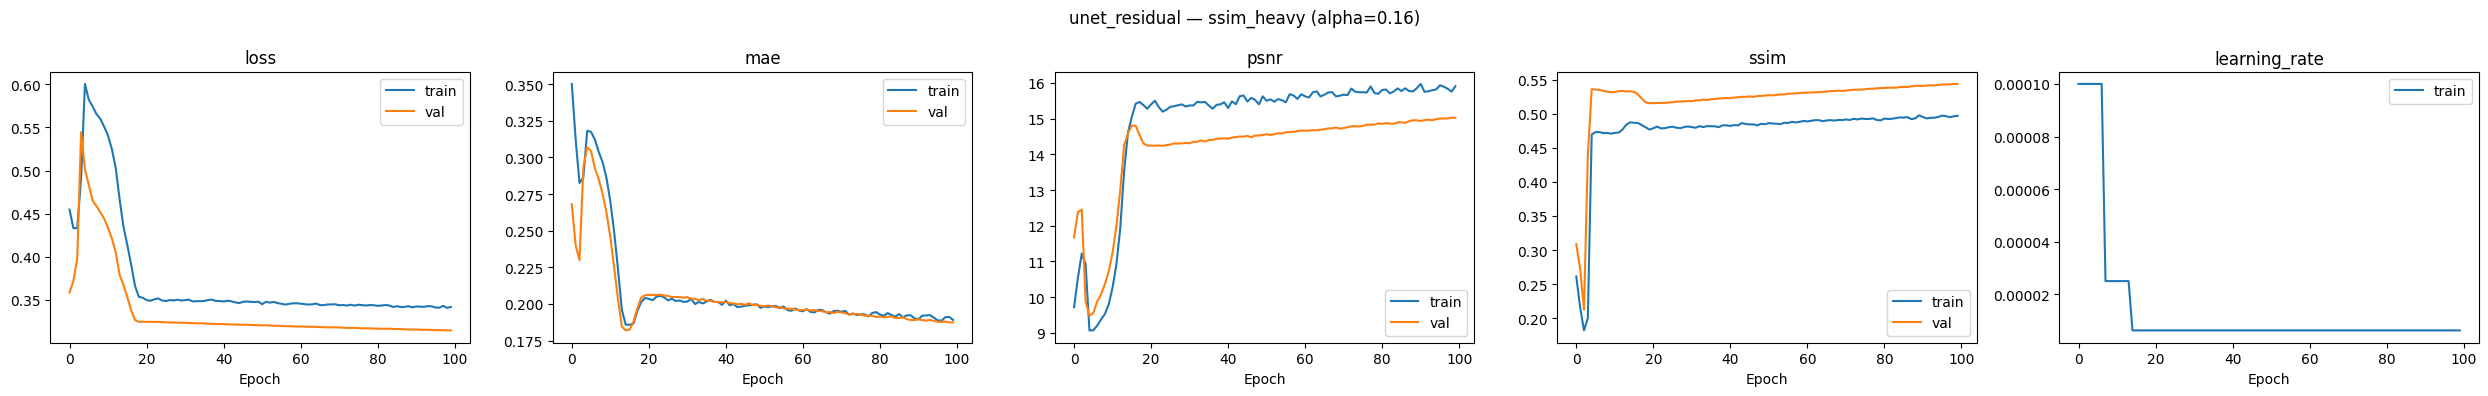

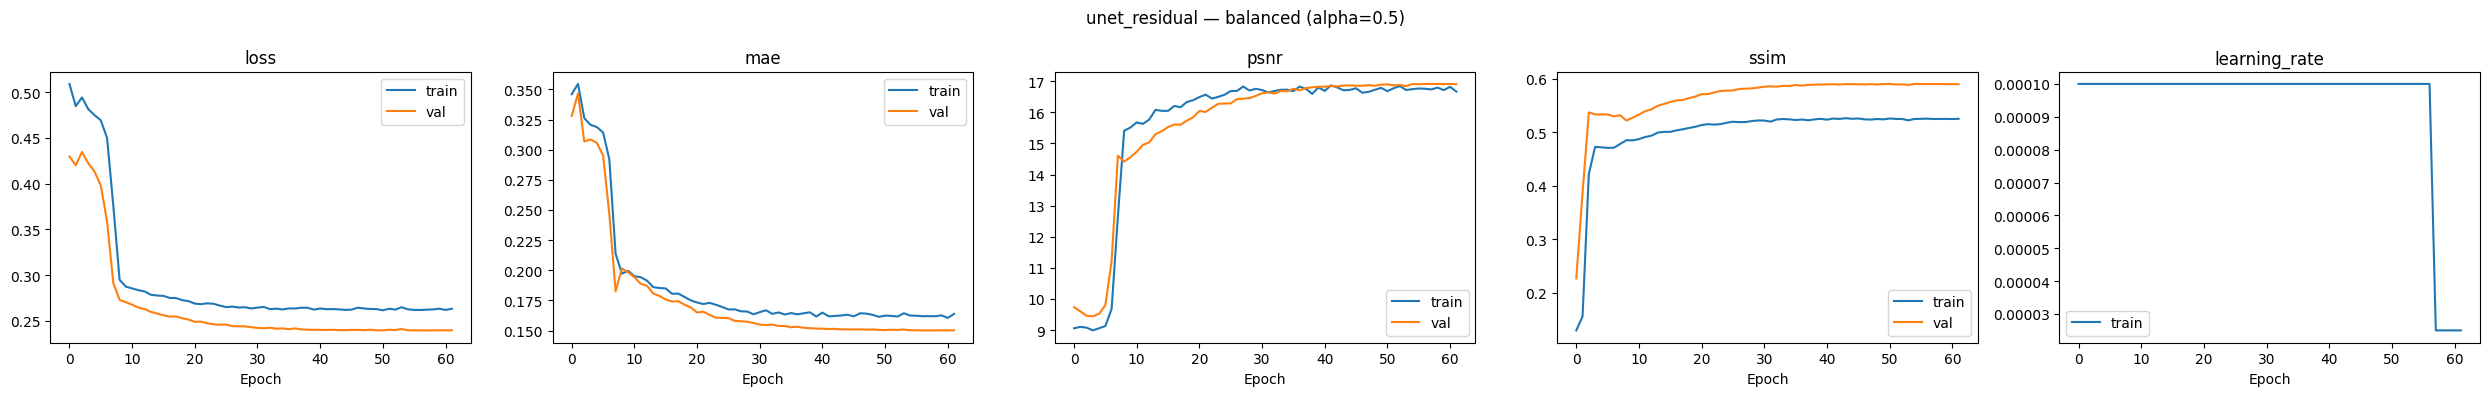

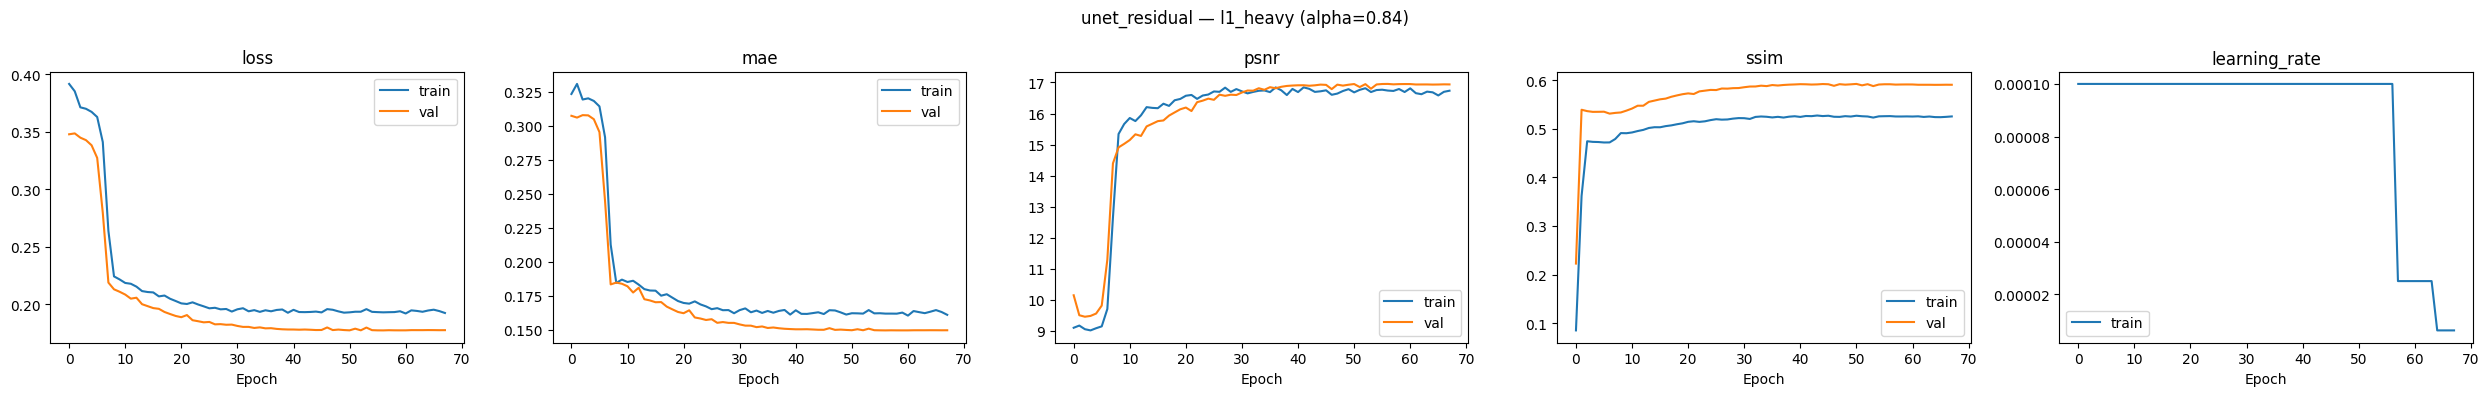

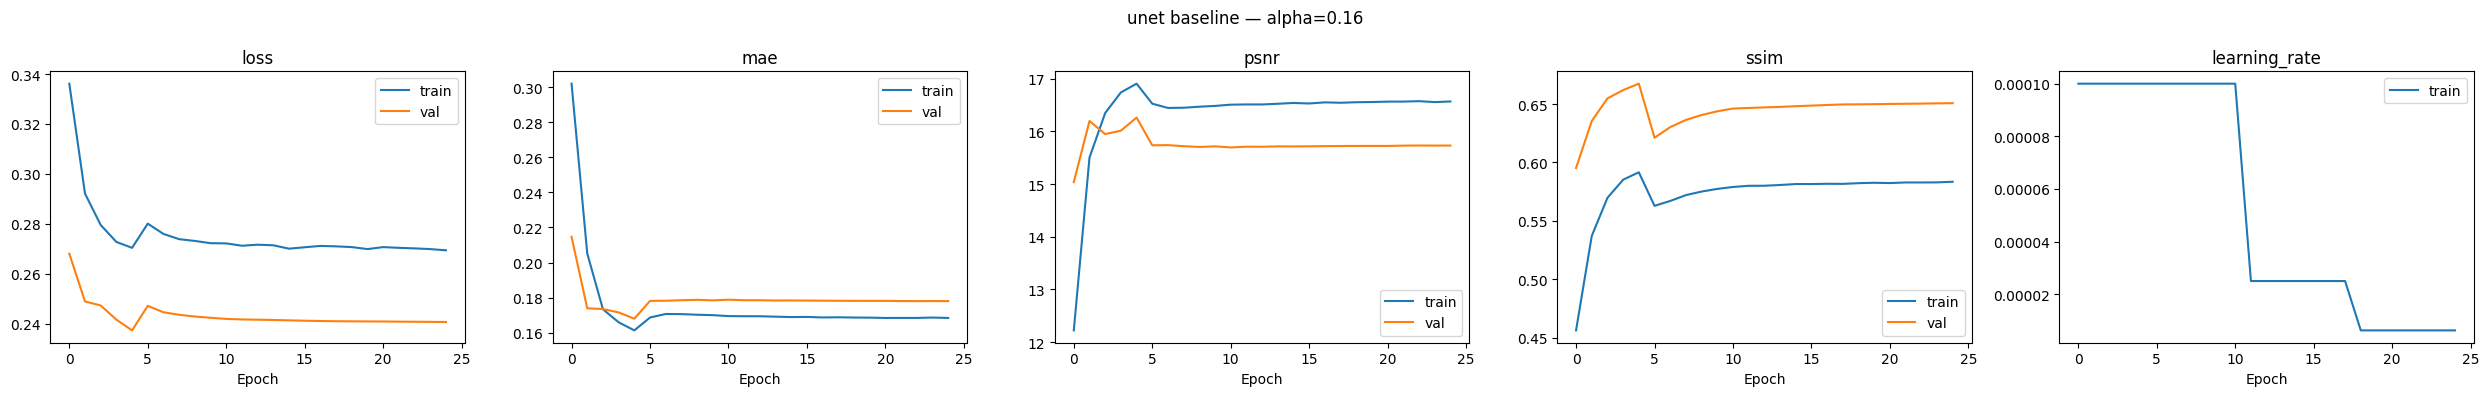

In [11]:
for label, alpha in LOSS_ALPHAS.items():
    plot_training_curves(histories[label], title=f"{ARCH} — {label} (alpha={alpha})")
    plt.show()

if baseline_history is not None:
    plot_training_curves(
        baseline_history,
        title=f"{BASELINE_ARCH} baseline — alpha={settings.LOSS_ALPHA}",
    )
    plt.show()

## 7. Summary

Checkpoints and where they landed. `val_mae` is reported alongside `val_loss`
because, unlike the loss, it does not carry the alpha weighting and so is comparable
across the sweep — a first, fidelity-only read on which alpha trained best. Expect
`l1_heavy` to win on MAE almost by construction; that is not the same as winning.

**Next steps, in order** — none of them belong in this notebook:

1. `033_evaluation_variants.ipynb` — pixel metrics on `data/test/`, all three runs
   plus `unet`. Add `unet_residual` to its `MODELS` list, pointing the off-default
   alphas at their `alpha_sweep/` directories.
2. `040`/`050` — detection AUROC and coherence, with `024` §6's confound in mind.
3. Only then decide whether the residual head earns a place in the standard set.

In [12]:
rows = []
for label, alpha in LOSS_ALPHAS.items():
    model_dir, _ = run_dirs(label, alpha)
    ckpt = model_dir / ARCH / "best_model.keras"
    hist = histories[label]
    rows.append(
        (
            f"{ARCH} ({label})",
            f"{alpha:.2f}",
            "found" if ckpt.exists() else "MISSING",
            f"{min(hist['val_loss']):.4f}",
            f"{min(hist['val_mae']):.4f}",
            str(ckpt),
        )
    )

if baseline_history is not None:
    ckpt = DEFAULT_DIR / BASELINE_ARCH / "best_model.keras"
    rows.append(
        (
            f"{BASELINE_ARCH} (baseline)",
            f"{settings.LOSS_ALPHA:.2f}",
            "found" if ckpt.exists() else "MISSING",
            f"{min(baseline_history['val_loss']):.4f}",
            f"{min(baseline_history['val_mae']):.4f}",
            str(ckpt),
        )
    )

fmt = "{:<26} {:<6} {:<8} {:<10} {:<10} {}"
print(fmt.format("run", "alpha", "ckpt", "val_loss", "val_mae", "path"))
for row in rows:
    print(fmt.format(*row))

run                        alpha  ckpt     val_loss   val_mae    path
unet_residual (ssim_heavy) 0.16   found    0.3144     0.1819     /Users/marcomanduca/Desktop/projects/deep_layers/models/deterministic/unet_residual/best_model.keras
unet_residual (balanced)   0.50   found    0.2394     0.1501     /Users/marcomanduca/Desktop/projects/deep_layers/models/alpha_sweep/alpha_0.50/unet_residual/best_model.keras
unet_residual (l1_heavy)   0.84   found    0.1774     0.1494     /Users/marcomanduca/Desktop/projects/deep_layers/models/alpha_sweep/alpha_0.84/unet_residual/best_model.keras
unet (baseline)            0.16   found    0.2373     0.1679     /Users/marcomanduca/Desktop/projects/deep_layers/models/deterministic/unet/best_model.keras
